In [1]:
from utils import * 
import numpy as np
from typing import NamedTuple
import shutil 
from matplotlib.lines import Line2D
from datetime import datetime
import itertools
import os
import re
import networkx as nx

%load_ext autoreload 
%autoreload 2

date = datetime.now().strftime("%m_%d_%Y")

%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# It seems pretty clear that cluster_1 and cluster_3 proteins interact, though it is not clear how, or if the cluster_1 interaction is compatible
# with the multimer form of cluster_2. For this analysis, I am going to focus on the structure for the bz_10 genes, which seem to have some of the highest ipTM scores. 
# I will aim to address the following questions:
#   (1) Are the predicted contacting residues between cluster_1 and cluster_3 the same in the hexameric structure versus the two monomers?
#   (2) Are there residues between cluster_1 and cluster_3 with high-confidence contact in the hexameric structure? 
#   (3) Are the contacting residues conserved in different genomes?
#   (4) Does the structure change in the presence or absence of ligands?

In [27]:
ALPHAFOLD_INPUT_DIR = '../data/genes/alphafold/af_input/'
ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output/'


In [4]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df = genes_df[genes_df.genome_id != 'bz_12'].copy()
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r'))).astype(int)
genes_df['gene_id'] = genes_df.index.values
genes_df = genes_df[genes_df.cluster_id.isin([1, 3])].copy()
genes_df['alphafold_id'] = genes_df.apply(lambda row : f'{row.genome_id}_cluster_{row.cluster_id}' + '_{n}mer', axis=1)

CLUSTER_1_SEQS = genes_df[genes_df.cluster_id == 1].set_index('genome_id').seq.to_dict()
CLUSTER_1_GENE_IDS = genes_df[genes_df.cluster_id == 1].set_index('genome_id').gene_id.to_dict()

In [44]:
dimer_outputs = {get_genome_id(path):AlphaFoldOutput(path) for path in glob.glob(os.path.join(ALPHAFOLD_OUTPUT_DIR, '*')) if (path.count('cluster_1') == 2)}
monomer_outputs = {genome_id:AlphaFoldOutput(os.path.join(ALPHAFOLD_OUTPUT_DIR, gene_id)) for genome_id, gene_id in CLUSTER_1_GENE_IDS.items()}

for genome_id in dimer_outputs:
    print(f'{genome_id} monomer pTM:\t', monomer_outputs[genome_id].get_ptms(best_model=True), end='\t\t')
    print(f'{genome_id} dimer pTM, ipTM:\t', dimer_outputs[genome_id].get_ptms(best_model=True), ',' , dimer_outputs[genome_id].get_iptms(best_model=True))


bz_11 monomer pTM:	 0.49		bz_11 dimer pTM, ipTM:	 0.51 , 0.44
bz_8 monomer pTM:	 0.46		bz_8 dimer pTM, ipTM:	 0.19 , 0.09
bz_2 monomer pTM:	 0.48		bz_2 dimer pTM, ipTM:	 0.28 , 0.16
bz_0 monomer pTM:	 0.46		bz_0 dimer pTM, ipTM:	 0.55 , 0.51
bz_7 monomer pTM:	 0.4		bz_7 dimer pTM, ipTM:	 0.17 , 0.09
bz_10 monomer pTM:	 0.47		bz_10 dimer pTM, ipTM:	 0.44 , 0.31
bz_5 monomer pTM:	 0.48		bz_5 dimer pTM, ipTM:	 0.56 , 0.53
bz_1 monomer pTM:	 0.49		bz_1 dimer pTM, ipTM:	 0.48 , 0.38
bz_9 monomer pTM:	 0.45		bz_9 dimer pTM, ipTM:	 0.51 , 0.47
bz_3 monomer pTM:	 0.5		bz_3 dimer pTM, ipTM:	 0.61 , 0.6
bz_4 monomer pTM:	 0.45		bz_4 dimer pTM, ipTM:	 0.54 , 0.5


In [15]:
contacts_df = pd.read_csv('analysis-1-ppi-contacts.csv')

contacts_df['cluster_ids'] = [', '.join(sorted(re.findall(r'cluster_\d+', name))) for name in contacts_df['name']]
contacts_df['genome_id'] = contacts_df.name.apply(get_genome_id)
contacts_df = contacts_df[contacts_df.cluster_ids == 'cluster_1, cluster_1'].copy()

contacts_df['gene_id_0'] = contacts_df.genome_id.map(CLUSTER_1_GENE_IDS)
contacts_df['gene_id_1'] = contacts_df.genome_id.map(CLUSTER_1_GENE_IDS)

filters = dict()
filters['low_contact_prob'] = contacts_df.contact_prob < 0.5

contacts_df = apply_filters(filters, contacts_df)

apply_filters: 2758 entries removed by low_contact_prob.


In [16]:
msa = MSAFile.from_file('../data/genes/cluster_1.afa')
contacts_df['msa_residue_num_0'] = contacts_df.apply(lambda row : msa.map_idx_to_msa(row.residue_num_0, row.gene_id_0), axis=1)
contacts_df['msa_residue_num_1'] = contacts_df.apply(lambda row : msa.map_idx_to_msa(row.residue_num_1, row.gene_id_1), axis=1)

In [62]:
# Note that, because there are 10 seeds, there should be 10 models per genome, and 11 genomes with both cluster_1 and cluster_3. 

def get_supported_contacts(contacts_df:pd.DataFrame, i:int=0, min_num_models:int=50, min_contact_prob=0.5):
    '''Obtain the contacts (as indices relative to the MSA) which are supported by at least min_num_models separate models. 
    In other words, if a residue participates in multiple contacts within the same model, only count the residue once.
    Note that the model names themselves are not unique, so need to account for the names when de-duplicating. '''
    contacts_df = contacts_df[contacts_df.contact_prob > min_contact_prob].copy()
    contacts_df = contacts_df.drop_duplicates(['model', 'name', f'msa_residue_num_{i}']) # Use the residue number mapped to the MSA so that they are comparable across genomes. 
    counts = contacts_df[f'msa_residue_num_{i}'].value_counts()
    counts = counts[counts > min_num_models].copy()
    print(f'get_supported_contacts: Maximum number of models supporting any contact is:', counts.max())
    return sorted(counts.index.astype(int).tolist())

print('cluster_1 supported contacts:', get_supported_contacts(contacts_df, i=0))

get_supported_contacts: Maximum number of models supporting any contact is: 59
cluster_1 supported contacts: [68, 122, 123, 124, 125, 126, 142]


In [63]:
contacts_df[contacts_df.msa_residue_num_0 == 122].genome_id.unique()

<StringArray>
['bz_0', 'bz_11', 'bz_3', 'bz_4', 'bz_5', 'bz_9']
Length: 6, dtype: str

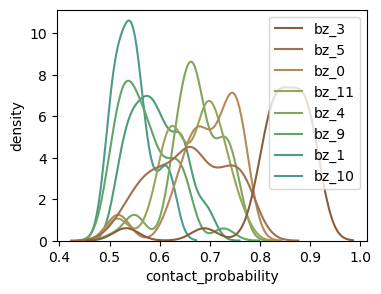

In [61]:
fig, ax = plt.subplots(figsize=(4, 3))

figure_df = contacts_df.sort_values('contact_prob', ascending=False)
figure_df = figure_df.drop_duplicates(['residue_num_0', 'name', 'model']) # Keep one entry for each residue per model (the one with the highest probability).
sns.kdeplot(figure_df, x='contact_prob', hue='genome_id', common_norm=False)
ax.set_ylabel('density')
ax.set_xlabel('contact_probability')
ax.get_legend().set_title('')
plt.show()
